# Chapter 7: Programming Languages

You already know how to program a classical computer. You write instructions,
a compiler or interpreter translates them, and a machine executes them. The
slogan is clean:

> **DATA + CONTROL = PROGRAMMING**

Quantum computing keeps that slogan but changes the ingredients. The data
now includes qubits in superposition. The control still runs on a classical
machine. The programming challenge is new: how do you write instructions for
hardware that obeys linear algebra instead of Boolean logic?

This chapter builds a working quantum assembly language in Python, runs
Deutsch's algorithm through it, surveys the landscape of higher-level quantum
languages, and ends by packaging everything into a reusable emulator class.

In [1]:
import numpy as np
from math import sqrt, pi, floor
import matplotlib.pyplot as plt

## 7.1 Programming in a Quantum World

Programming a classical machine is immediate: you tell the processor what to
do with bits, and it does it. Programming a quantum machine is less obvious.
The hardware manipulates qubits that exist in superposition and entanglement,
obeying physics we cannot observe directly. We can initialize quantum states,
apply unitary transformations, and measure. That is all.

The updated slogan:

> **QUANTUM DATA + CONTROL = QUANTUM PROGRAMMING**

The control remains classical. You write ordinary code in C, Python, or
whatever language you prefer. When you need quantum power, you insert a
few lines that talk to the quantum device. The device handles the qubits;
your classical code handles everything else.

### The QRAM Model

Three candidate architectures exist for quantum computation: quantum circuits,
quantum Turing machines, and the **Quantum Random Access Memory Model (QRAM)**.
They are provably equivalent in power, but QRAM is the most natural for
programming.

QRAM splits the computer into two parts:

- A **classical computer** (the master), running your main program
- A **quantum processor** (the servant), accessed on request

The programmer writes classical code. When she needs the quantum device, she
sends it instructions through a **Quantum Hardware Interface (QHI)**. She
never needs to know how qubits are physically stored, initialized, or measured.
The only thing she may need to know is the device's capacity: how many qubits
are available.

Think of it like a GPU: your main code runs on the CPU, but when you need
parallel matrix multiplications, you offload them to the graphics card through
a thin API. Same idea here, with a quantum processor replacing the GPU.

## 7.2 Quantum Assembly Programming

Classical assembly languages abstract hardware into registers and instructions.
We can do the same for quantum hardware. The assembler we build here is a
teaching tool, not a production standard, but it captures the essential
structure of real quantum assembly languages.

The quantum device holds **quantum registers** (q-registers): addressable
sequences of qubits. Each q-register has a fixed size and a unique identifier.
For our purposes, every register holds 8 qubits (a "qubyte").

One constraint that classical assemblers lack: the **no-cloning theorem**
forbids copying one q-register into another. There is no quantum MOV instruction.

### The Four Basic Instructions

Our assembler has four instructions:

**1. INITIALIZE R [INPUT]**

Allocate a q-register named R and set it to a classical bit string. If no
input is given, all qubits default to $|0\rangle$. Initialization "cools"
every qubit to its ground state, then flips the ones indicated by INPUT.

**2. SELECT S R OFFSET NUMQUBITS**

Create a subregister variable S pointing to NUMQUBITS qubits of R, starting
at position OFFSET (zero-indexed, like C arrays).

**3. APPLY U R**

Apply the unitary gate U to register R. The gate's dimension must match the
register's size.

**4. MEASURE R RES**

Measure register R and store the classical result in variable RES (a bit
array). Measurement collapses the quantum state.

### Building Gates

The assembler assumes a universal gate set:

$$\mathbf{GATES} = \{H, R_\theta, I_n, CNOT\}$$

where $H$ is Hadamard, $R_\theta$ is a phase shift by angle $\theta$,
$I_n$ is the $n \times n$ identity, and $CNOT$ is the controlled-NOT.

Gates compose through three macro operations:

- **CONCAT U1 U2**: sequential composition (matrix multiplication, right to left)
- **TENSOR U1 U2**: parallel composition (Kronecker product)
- **INVERSE U1**: the adjoint $U_1^\dagger$

The identity gate handles padding. To apply Hadamard to only the first qubit
of a 4-qubit register, tensor $H$ with $I_2$ (leaving the last two qubits
unchanged).

### Programming Drill 7.2.1: Quantum Assembly Simulator

The textbook asks for a lexical analyzer. We will go further: a complete
simulator that implements all four instructions plus the gate macros.
The simulator maintains a dictionary of q-registers (as state vectors)
and a dictionary of named gates (as matrices).

In [2]:
class QuantumAssembler:
    """A simulator for the QRAM quantum assembly language.
    
    Registers are stored as complex state vectors of length 2^n.
    Gates are stored as complex matrices of size 2^n x 2^n.
    """
    
    def __init__(self):
        self.registers = {}      # name -> state vector (np.array)
        self.reg_sizes = {}      # name -> number of qubits
        self.gates = {}          # name -> unitary matrix
        self.classical = {}      # name -> classical bit array
        self._init_builtin_gates()
    
    def _init_builtin_gates(self):
        """Load the standard gate set: H, CNOT, I_n, R_theta."""
        # Hadamard
        self.gates['H'] = np.array([[1, 1], [1, -1]]) / sqrt(2)
        
        # CNOT
        self.gates['CNOT'] = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0],
            [0, 0, 0, 1],
            [0, 0, 1, 0]
        ], dtype=complex)
        
        # Pauli X (NOT)
        self.gates['X'] = np.array([[0, 1], [1, 0]], dtype=complex)
        
        # Identity gates for various sizes
        for k in range(1, 9):
            self.gates[f'I{k}'] = np.eye(2**k, dtype=complex)
    
    def phase_gate(self, theta):
        """Phase shift gate R_theta."""
        return np.array([[1, 0], [0, np.exp(1j * theta)]], dtype=complex)
    
    # ---- INSTRUCTION 1: INITIALIZE ----
    def initialize(self, name, n_qubits=8, bits=None):
        """INITIALIZE R [INPUT]
        
        Create a register of n_qubits, set to |bits> if provided,
        otherwise |00...0>.
        """
        N = 2 ** n_qubits
        state = np.zeros(N, dtype=complex)
        if bits is None:
            state[0] = 1.0
        else:
            # bits is a string like '00001111' or a list
            if isinstance(bits, str):
                idx = int(bits, 2)
            else:
                idx = int(''.join(str(b) for b in bits), 2)
            state[idx] = 1.0
        self.registers[name] = state
        self.reg_sizes[name] = n_qubits
        return self
    
    # ---- INSTRUCTION 2: SELECT ----
    def select(self, sub_name, reg_name, offset, num_qubits):
        """SELECT S R OFFSET NUMQUBITS
        
        Create a subregister variable pointing to specific qubits.
        Stored as metadata; used when applying gates or measuring.
        """
        self.registers[sub_name] = {
            'parent': reg_name,
            'offset': offset,
            'size': num_qubits
        }
        self.reg_sizes[sub_name] = num_qubits
        return self
    
    # ---- INSTRUCTION 3: APPLY ----
    def apply(self, gate_name, reg_name):
        """APPLY U R
        
        Apply the named gate to the register. Gate dimensions must
        match the register size.
        """
        gate = self.gates[gate_name]
        state = self.registers[reg_name]
        if isinstance(state, dict):
            raise ValueError(f"Cannot apply gate to subregister '{reg_name}' directly. "
                           "Apply to the parent register instead.")
        self.registers[reg_name] = gate @ state
        return self
    
    # ---- INSTRUCTION 4: MEASURE ----
    def measure(self, reg_name, result_name=None):
        """MEASURE R RES
        
        Measure the register. Collapse the state to a basis state
        chosen with probability |amplitude|^2. Store the classical
        result (as a bit string) in result_name.
        """
        state = self.registers[reg_name]
        if isinstance(state, dict):
            raise ValueError("Subregister measurement not yet implemented.")
        
        probs = np.abs(state) ** 2
        probs = probs / probs.sum()  # normalize for floating-point safety
        N = len(state)
        n_qubits = self.reg_sizes[reg_name]
        
        outcome = np.random.choice(N, p=probs)
        bits = format(outcome, f'0{n_qubits}b')
        
        # Collapse the state
        new_state = np.zeros(N, dtype=complex)
        new_state[outcome] = 1.0
        self.registers[reg_name] = new_state
        
        if result_name:
            self.classical[result_name] = bits
        
        return bits
    
    # ---- GATE MACROS ----
    def concat(self, result_name, gate1_name, gate2_name):
        """U CONCAT U1 U2: sequential composition (U1 * U2)."""
        self.gates[result_name] = self.gates[gate1_name] @ self.gates[gate2_name]
        return self
    
    def tensor(self, result_name, gate1_name, gate2_name):
        """U TENSOR U1 U2: parallel composition (Kronecker product)."""
        self.gates[result_name] = np.kron(self.gates[gate1_name],
                                          self.gates[gate2_name])
        return self
    
    def inverse(self, result_name, gate_name):
        """U INVERSE U1: adjoint (conjugate transpose)."""
        self.gates[result_name] = self.gates[gate_name].conj().T
        return self
    
    # ---- UTILITIES ----
    def get_state(self, reg_name):
        """Return the current state vector of a register."""
        return self.registers[reg_name]
    
    def get_probs(self, reg_name):
        """Return measurement probabilities."""
        state = self.registers[reg_name]
        return np.abs(state) ** 2
    
    def state_str(self, reg_name):
        """Pretty-print the state as a sum of kets."""
        state = self.registers[reg_name]
        n = self.reg_sizes[reg_name]
        terms = []
        for i, amp in enumerate(state):
            if abs(amp) > 1e-10:
                label = format(i, f'0{n}b')
                if amp.imag == 0:
                    terms.append(f'{amp.real:+.4f}|{label}>')
                else:
                    terms.append(f'({amp:.4f})|{label}>')
        return ' '.join(terms)


print('QuantumAssembler ready.')

QuantumAssembler ready.


### Example 7.2.1: Initialization

Initialize a register of 8 qubits. First to $|00000000\rangle$ (the default),
then reinitialize it with the bit array $[00001111]$.

In [3]:
qa = QuantumAssembler()

# INITIALIZE R1 (default: all zeros)
qa.initialize('R1', n_qubits=8)
print('R1 after default init:', qa.state_str('R1'))

# INITIALIZE R1 [00001111]
qa.initialize('R1', n_qubits=8, bits='00001111')
print('R1 after init with 00001111:', qa.state_str('R1'))

R1 after default init: +1.0000|00000000>
R1 after init with 00001111: +1.0000|00001111>


### Example 7.2.4: A Complete Assembly Program

The textbook gives this fragment:

```
INITIALIZE R 2
U TENSOR H H
APPLY U R
MEASURE R RES
```

Line by line:

1. Allocate a 2-qubit register, initialized to $|00\rangle$.
2. Build $U = H \otimes H$, the 4x4 matrix that applies Hadamard to each qubit.
3. Apply $U$ to R. The state becomes $\frac{1}{2}(|00\rangle + |01\rangle + |10\rangle + |11\rangle)$.
4. Measure. Each outcome has probability $|1/2|^2 = 1/4$.

In [4]:
qa = QuantumAssembler()

# INITIALIZE R 2
qa.initialize('R', n_qubits=2)

# U TENSOR H H
qa.tensor('U', 'H', 'H')

# APPLY U R
qa.apply('U', 'R')

print('State after H x H:')
print(qa.state_str('R'))
print()
print('Probabilities:', np.round(qa.get_probs('R'), 4))
print()

# Verify: each coefficient is 1/2, each probability is 1/4
assert np.allclose(qa.get_probs('R'), [0.25, 0.25, 0.25, 0.25])

# MEASURE R RES
result = qa.measure('R', 'RES')
print(f'Measurement result: {result}')
print(f'Probability of |11>: 0.25')

State after H x H:
+0.5000|00> +0.5000|01> +0.5000|10> +0.5000|11>

Probabilities: [0.25 0.25 0.25 0.25]

Measurement result: 10
Probability of |11>: 0.25


### Example 7.2.3: Gate Composition

The assembler's CONCAT, TENSOR, and INVERSE macros let you build complex
unitaries from primitives. The textbook computes:

```
U1 CONCAT R_pi/4 R_pi/2
U2 CONCAT U1 U1
U3 CONCAT U2 H
```

Working through the matrix products:

$$U_3 = R_{\pi/4} \cdot R_{\pi/2} \cdot R_{\pi/4} \cdot R_{\pi/2} \cdot H$$

Each $R_\theta$ is a phase shift: $\begin{bmatrix} 1 & 0 \\ 0 & e^{i\theta} \end{bmatrix}$.

In [5]:
qa = QuantumAssembler()

# Register phase gates
qa.gates['Rpi4'] = qa.phase_gate(pi / 4)
qa.gates['Rpi2'] = qa.phase_gate(pi / 2)

# U1 CONCAT Rpi4 Rpi2   (= Rpi4 * Rpi2)
qa.concat('U1', 'Rpi4', 'Rpi2')

# U2 CONCAT U1 U1       (= U1 * U1)
qa.concat('U2', 'U1', 'U1')

# U3 CONCAT U2 H        (= U2 * H)
qa.concat('U3', 'U2', 'H')

print('U3 matrix:')
print(np.round(qa.gates['U3'], 5))
print()

# Verify: U3 should be unitary
U3 = qa.gates['U3']
print('U3 is unitary:', np.allclose(U3 @ U3.conj().T, np.eye(2)))

U3 matrix:
[[ 0.70711+0.j       0.70711+0.j     ]
 [-0.     -0.70711j  0.     +0.70711j]]

U3 is unitary: True


### Exercise 7.2.1

Consider the snippet:
```
INITIALIZE R1 [01110001]
SELECT S1 R1 2 4
SELECT S2 S1 0 2
```

S1 selects qubits 2, 3, 4, 5 of R1 (the bits `1100` from `01110001`).
S2 then selects qubits 0, 1 of S1, which correspond to qubits 2, 3
of R1 (the bits `11`).

So S2 points to qubits 2 and 3 of R1.

In [6]:
# Exercise 7.2.1: trace the subregister selections
qa = QuantumAssembler()
qa.initialize('R1', n_qubits=8, bits='01110001')

# R1 = 01110001
# Indices: 0=0, 1=1, 2=1, 3=1, 4=0, 5=0, 6=0, 7=1
bits = '01110001'
print(f'R1 = {bits}')
print(f'S1 = R1[2:6] = {bits[2:6]}')  # qubits 2,3,4,5
print(f'S2 = S1[0:2] = {bits[2:4]}')  # qubits 2,3 of R1
print()
print('S2 points to qubits 2 and 3 of R1, which hold bits:', bits[2:4])

R1 = 01110001
S1 = R1[2:6] = 1100
S2 = S1[0:2] = 11

S2 points to qubits 2 and 3 of R1, which hold bits: 11


### Exercise 7.2.2

```
U1 TENSOR CNOT CNOT
U2 CONCAT U1 U1
```

$U_1 = CNOT \otimes CNOT$ is a 16x16 matrix acting on 4 qubits.
It applies CNOT to qubits (0,1) and CNOT to qubits (2,3) in parallel.

$U_2 = U_1 \cdot U_1 = U_1^2$. Since CNOT is self-inverse ($CNOT^2 = I$),
and tensor product distributes over matrix multiplication,
$U_2 = (CNOT \otimes CNOT)^2 = CNOT^2 \otimes CNOT^2 = I_4$.

So $U_2$ is the 16x16 identity.

In [7]:
# Exercise 7.2.2: verify U2 = I
qa = QuantumAssembler()
qa.tensor('U1', 'CNOT', 'CNOT')
qa.concat('U2', 'U1', 'U1')

print('U1 shape:', qa.gates['U1'].shape)
print('U2 is identity:', np.allclose(qa.gates['U2'], np.eye(16)))

U1 shape: (16, 16)
U2 is identity: True


### Exercise 7.2.3

Write assembler code for the unitary:

$$U = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & -1 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & -1 \end{bmatrix}$$

This matrix negates the amplitude whenever the second qubit is $|1\rangle$.
That is $I \otimes Z$ where $Z = \begin{bmatrix}1 & 0 \\ 0 & -1\end{bmatrix}$.
In assembler: `U TENSOR I1 R_pi` (since $R_\pi = Z$).

Alternatively, $R_\pi$ applied to the second qubit while leaving the first alone.

In [8]:
# Exercise 7.2.3
qa = QuantumAssembler()
qa.gates['Rpi'] = qa.phase_gate(pi)  # Z gate = R_pi

# U TENSOR I1 Rpi
qa.tensor('U', 'I1', 'Rpi')

target = np.diag([1, -1, 1, -1]).astype(complex)
print('U =')
print(np.round(qa.gates['U'].real, 4))
print()
print('Matches target:', np.allclose(qa.gates['U'], target))

U =
[[ 1.  0.  0.  0.]
 [ 0. -1.  0. -0.]
 [ 0.  0.  1.  0.]
 [ 0. -0.  0. -1.]]

Matches target: True


### Exercise 7.2.4

Consider the quantum assembler code:

```
INITIALIZE R 2
U TENSOR H I2
APPLY U R
SELECT S1 R 0 1
MEASURE S1 RES
APPLY CNOT R
MEASURE R RES
```

After `U TENSOR H I2` and `APPLY U R`, the state is
$\frac{1}{\sqrt{2}}(|00\rangle + |10\rangle)$. Measuring the first qubit
gives $|0\rangle$ or $|1\rangle$ each with probability 1/2. If we get $|0\rangle$,
the state collapses to $|00\rangle$; CNOT then gives $|00\rangle$.
If we get $|1\rangle$, state collapses to $|10\rangle$; CNOT gives $|11\rangle$.

The probability of measuring $|10\rangle$ at the end is $1/2$ (when the first
measurement gives $|0\rangle$ and CNOT leaves $|00\rangle$... wait, that gives
$|00\rangle$). Actually, the result of `MEASURE R RES` is either $|00\rangle$
or $|11\rangle$, each with probability 1/2. The probability of $|10\rangle$ is 0.

In [9]:
# Exercise 7.2.4: simulate the program
# We run it many times to see the distribution
np.random.seed(42)
results = {'00': 0, '01': 0, '10': 0, '11': 0}
n_trials = 10000

for _ in range(n_trials):
    qa = QuantumAssembler()
    qa.initialize('R', n_qubits=2)
    
    # U TENSOR H I1  (H on qubit 0, identity on qubit 1)
    qa.tensor('U', 'H', 'I1')
    qa.apply('U', 'R')
    
    # Measure first qubit (simulate by measuring full register
    # and extracting first bit, then collapsing)
    state = qa.get_state('R')
    # Probabilities for each basis state
    probs = np.abs(state) ** 2
    outcome = np.random.choice(4, p=probs/probs.sum())
    bits = format(outcome, '02b')
    # Collapse to the subspace consistent with first-qubit measurement
    first_bit = bits[0]
    collapsed = np.zeros(4, dtype=complex)
    for j in range(4):
        if format(j, '02b')[0] == first_bit:
            collapsed[j] = state[j]
    norm = np.linalg.norm(collapsed)
    if norm > 0:
        collapsed /= norm
    qa.registers['R'] = collapsed
    
    # APPLY CNOT R
    qa.apply('CNOT', 'R')
    
    # MEASURE R RES
    res = qa.measure('R', 'RES')
    results[res] += 1

print('Distribution over', n_trials, 'trials:')
for k, v in sorted(results.items()):
    print(f'  |{k}>: {v/n_trials:.3f}')
print()
print('As expected: only |00> and |11> occur, each with ~50%.')
print('Probability of |10>: 0')

Distribution over 10000 trials:
  |00>: 0.501
  |01>: 0.000
  |10>: 0.000
  |11>: 0.499

As expected: only |00> and |11> occur, each with ~50%.
Probability of |10>: 0


### Exercise 7.2.5

Go back to Exercise 7.2.4. After initialization, add a while loop that
includes all other instructions and stops only when $RES = [10]$.
Is it guaranteed to terminate?

The program ends up looking like:
```
INITIALIZE R 2
while RES != [10]:
    U TENSOR H I2
    APPLY U R
    SELECT S1 R 0 1
    MEASURE S1 RES
    APPLY CNOT R
    MEASURE R RES
```

Since the final measurement can only produce $|00\rangle$ or $|11\rangle$
(never $|10\rangle$), the loop condition is never satisfied.
The program **never terminates**.

In [10]:
# Exercise 7.2.5: the loop never terminates because
# the CNOT entanglement ensures we only ever measure |00> or |11>.
# We can verify: run the inner block 1000 times and confirm |10> never appears.

np.random.seed(0)
got_10 = False
for _ in range(1000):
    qa = QuantumAssembler()
    qa.initialize('R', n_qubits=2)
    qa.tensor('U', 'H', 'I1')
    qa.apply('U', 'R')
    # Partial measure + CNOT
    state = qa.get_state('R')
    probs = np.abs(state) ** 2
    outcome = np.random.choice(4, p=probs/probs.sum())
    first_bit = format(outcome, '02b')[0]
    collapsed = np.zeros(4, dtype=complex)
    for j in range(4):
        if format(j, '02b')[0] == first_bit:
            collapsed[j] = state[j]
    norm = np.linalg.norm(collapsed)
    if norm > 0: collapsed /= norm
    qa.registers['R'] = collapsed
    qa.apply('CNOT', 'R')
    res = qa.measure('R')
    if res == '10':
        got_10 = True
        break

print(f'Got |10> in 1000 trials: {got_10}')
print('The while loop would run forever.')

Got |10> in 1000 trials: False
The while loop would run forever.


### Exercise 7.2.6: Deutsch's Algorithm in Quantum Assembly

Deutsch's algorithm determines whether a function $f:\{0,1\}\to\{0,1\}$
is constant or balanced, using a single query. The circuit from Chapter 6:

1. Initialize two qubits to $|01\rangle$ (first qubit 0, second qubit 1)
2. Apply $H \otimes H$
3. Apply $U_f$ (the oracle for $f$)
4. Apply $H \otimes I$ to the first qubit
5. Measure the first qubit: 0 means constant, 1 means balanced

We implement this in our assembler for all four possible single-bit functions.

In [11]:
def build_Uf(f):
    """Build the 4x4 unitary U_f for a function f:{0,1} -> {0,1}.
    
    U_f|x,y> = |x, y XOR f(x)>
    """
    U = np.zeros((4, 4), dtype=complex)
    for x in range(2):
        for y in range(2):
            input_idx = x * 2 + y
            output_y = y ^ f(x)  # XOR
            output_idx = x * 2 + output_y
            U[output_idx, input_idx] = 1
    return U


# The four single-bit functions
functions = {
    'f0 (constant 0)': lambda x: 0,
    'f1 (constant 1)': lambda x: 1,
    'f_id (balanced)': lambda x: x,
    'f_not (balanced)': lambda x: 1 - x,
}

print('Deutsch\'s Algorithm via Quantum Assembler')
print('=' * 50)

for name, f in functions.items():
    qa = QuantumAssembler()
    
    # Step 1: INITIALIZE R [01]  (|0>|1>)
    qa.initialize('R', n_qubits=2, bits='01')
    
    # Step 2: U_HH TENSOR H H; APPLY U_HH R
    qa.tensor('HH', 'H', 'H')
    qa.apply('HH', 'R')
    
    # Step 3: Register and apply U_f
    qa.gates['Uf'] = build_Uf(f)
    qa.apply('Uf', 'R')
    
    # Step 4: Apply H to first qubit only: U TENSOR H I1
    qa.tensor('HI', 'H', 'I1')
    qa.apply('HI', 'R')
    
    # Step 5: Check amplitudes of first qubit
    state = qa.get_state('R')
    # Probability first qubit is |0>: sum |amp|^2 for states 00, 01
    p0 = abs(state[0])**2 + abs(state[1])**2
    p1 = abs(state[2])**2 + abs(state[3])**2
    result = 'constant' if p0 > 0.5 else 'balanced'
    
    print(f'{name}:')
    print(f'  P(first qubit=0) = {p0:.4f}, P(first qubit=1) = {p1:.4f}')
    print(f'  Verdict: {result}')
    print()

Deutsch's Algorithm via Quantum Assembler
f0 (constant 0):
  P(first qubit=0) = 1.0000, P(first qubit=1) = 0.0000
  Verdict: constant

f1 (constant 1):
  P(first qubit=0) = 1.0000, P(first qubit=1) = 0.0000
  Verdict: constant

f_id (balanced):
  P(first qubit=0) = 0.0000, P(first qubit=1) = 1.0000
  Verdict: balanced

f_not (balanced):
  P(first qubit=0) = 0.0000, P(first qubit=1) = 1.0000
  Verdict: balanced



## 7.3 Toward Higher-Level Quantum Programming

The assembler from Section 7.2 can express any quantum algorithm, but it is
painful to use. It has only one data type: quantum binary strings. Shor's
algorithm operates on integers, not bit strings. If you want to add two
quantum integers, you must first represent them as sequences of qubits,
then find the unitary transformation that performs addition, then decompose
that unitary into basic gates. This is the quantum analog of writing all
your programs in machine code.

The path forward follows the same trajectory classical computing took:
build higher-level languages with richer type systems and let a compiler
handle the gate decomposition.

### Constructing $U_f$ for Classical Functions

A key challenge in quantum programming: given a classical function
$f:\{0,1\}^n \to \{0,1\}^n$, build the corresponding unitary $U_f$.

If $f$ is invertible (a permutation), the job is straightforward. Define
$U_f$ as the linear extension of $f$ on basis states:

$$U_f(c_0|0\ldots0\rangle + c_1|0\ldots1\rangle + \cdots) = c_0|f(0\ldots0)\rangle + c_1|f(0\ldots1)\rangle + \cdots$$

This is linear and unitary (permutation matrices are unitary).

If $f$ is **not** invertible, $U_f$ built this way fails to be unitary.
The fix: carry the input along with the output, making the map reversible:

$$U_f: |\mathbf{x}\rangle|\mathbf{y}\rangle \mapsto |\mathbf{x}\rangle|f(\mathbf{x}) \oplus \mathbf{y}\rangle$$

This doubles the register size (we need $n$ extra "scratch" qubits), but
the result is always unitary. The input register passes through unchanged;
the output register receives $f(\mathbf{x})$ XORed with whatever was there.

### Exercise 7.3.1

Verify that $f$ invertible implies $U_f$ is a unitary map.

If $f$ is a permutation, then $U_f$ is a permutation matrix: it maps each
basis vector to a distinct basis vector. A permutation matrix $P$ satisfies
$P^\dagger P = I$ because its columns are orthonormal (each is a standard
basis vector, and all are distinct). Therefore $U_f$ is unitary.

In [12]:
# Exercise 7.3.1: demonstrate with a concrete invertible function
# f: {00, 01, 10, 11} -> {01, 00, 11, 10}  (just flips the last bit)

def f_invertible(x_bits):
    """Flip the last bit."""
    x = int(x_bits, 2)
    return format(x ^ 1, f'0{len(x_bits)}b')

n = 2
N = 2**n
Uf = np.zeros((N, N), dtype=complex)
for i in range(N):
    bits_in = format(i, f'0{n}b')
    bits_out = f_invertible(bits_in)
    j = int(bits_out, 2)
    Uf[j, i] = 1

print('U_f (permutation matrix):')
print(Uf.real.astype(int))
print()
print('U_f^dag * U_f = I:', np.allclose(Uf.conj().T @ Uf, np.eye(N)))

U_f (permutation matrix):
[[0 1 0 0]
 [1 0 0 0]
 [0 0 0 1]
 [0 0 1 0]]

U_f^dag * U_f = I: True


### Exercise 7.3.2

Provide an example of a noninvertible $f$ that generates a nonunitary map
when we naively extend it linearly.

Take $f(0) = 0, f(1) = 0$ (the constant-zero function on one bit).
The naive $U_f$ sends both $|0\rangle$ and $|1\rangle$ to $|0\rangle$,
giving the matrix $\begin{bmatrix}1 & 1\\ 0 & 0\end{bmatrix}$.
This is not even an isometry, let alone unitary.

In [13]:
# Exercise 7.3.2: noninvertible f => nonunitary
# f(0) = 0, f(1) = 0
Uf_bad = np.array([[1, 1], [0, 0]], dtype=complex)
print('Naive U_f for constant-zero function:')
print(Uf_bad)
print()
print('U_f^dag * U_f =')
print(Uf_bad.conj().T @ Uf_bad)
print()
print('Is unitary:', np.allclose(Uf_bad.conj().T @ Uf_bad, np.eye(2)))
print('Columns are not orthonormal: both map to |0>, so information is lost.')

Naive U_f for constant-zero function:
[[1.+0.j 1.+0.j]
 [0.+0.j 0.+0.j]]

U_f^dag * U_f =
[[1.+0.j 1.+0.j]
 [1.+0.j 1.+0.j]]

Is unitary: False
Columns are not orthonormal: both map to |0>, so information is lost.


### Exercise 7.3.3

Prove that $U_f: |\mathbf{x}\rangle|\mathbf{y}\rangle \mapsto |\mathbf{x}\rangle|f(\mathbf{x})\oplus\mathbf{y}\rangle$
is a reversible map from $2^{2n}$ to itself.

Apply $U_f$ twice: $U_f(|\mathbf{x}\rangle|f(\mathbf{x})\oplus\mathbf{y}\rangle)
= |\mathbf{x}\rangle|f(\mathbf{x})\oplus f(\mathbf{x})\oplus\mathbf{y}\rangle
= |\mathbf{x}\rangle|\mathbf{y}\rangle$.

So $U_f$ is its own inverse, hence bijective (a permutation), hence reversible.

In [14]:
# Exercise 7.3.3: verify U_f is self-inverse for a non-invertible f
# f: {00,01,10,11} -> {00,00,01,11} (not invertible)

def f_noninv(x):
    table = {0: 0, 1: 0, 2: 1, 3: 3}
    return table[x]

n = 2
N = 2**(2*n)  # 4 input bits total (x,y each 2 bits)
Uf = np.zeros((N, N), dtype=complex)

for x in range(4):
    for y in range(4):
        input_idx = x * 4 + y
        output_y = y ^ f_noninv(x)
        output_idx = x * 4 + output_y
        Uf[output_idx, input_idx] = 1

print('U_f is unitary:', np.allclose(Uf.conj().T @ Uf, np.eye(N)))
print('U_f is self-inverse (U_f^2 = I):', np.allclose(Uf @ Uf, np.eye(N)))

U_f is unitary: True
U_f is self-inverse (U_f^2 = I): True


### Example 7.3.1 and Exercise 7.3.4

The textbook shows a concrete non-invertible function on 2 bits:

| x  | f(x) |
|:--:|:----:|
| 00 | 00   |
| 01 | 00   |
| 10 | 01   |
| 11 | 11   |

To make this reversible, we build the 4-qubit map
$|x,y\rangle \mapsto |x, f(x)\oplus y\rangle$.

Exercise 7.3.4 asks for a slightly different function:
$f(n) = n+2$ if $n \le 13$, and $f(n) = n$ otherwise
(on the integers 0 through 15, expressed in 4 bits).

In [15]:
# Example 7.3.1: build U_f for the non-invertible 2-bit function
def f_example(x):
    table = {0: 0, 1: 0, 2: 1, 3: 3}
    return table[x]

n = 2
N = 2**(2*n)
Uf = np.zeros((N, N), dtype=complex)
for x in range(4):
    for y in range(4):
        in_idx = x * 4 + y
        out_y = y ^ f_example(x)
        out_idx = x * 4 + out_y
        Uf[out_idx, in_idx] = 1

print('U_f for Example 7.3.1:')
print('  Shape:', Uf.shape)
print('  Is unitary:', np.allclose(Uf @ Uf.conj().T, np.eye(N)))
print()

# Verify: |11,00> -> |11, f(11) XOR 00> = |11, 11>
state = np.zeros(N, dtype=complex)
state[3 * 4 + 0] = 1  # |x=11, y=00>
result = Uf @ state
idx = np.argmax(np.abs(result))
x_out, y_out = idx // 4, idx % 4
print(f'|11,00> -> |{x_out:02b},{y_out:02b}>  (f(11)=11, 11 XOR 00 = 11)')

print()
print('--- Exercise 7.3.4 ---')
# f(n) = n+2 if n <= 13, else f(n) = n, on 4-bit integers
def f_734(n):
    return (n + 2) if n <= 13 else n

n = 4
N = 2**(2*n)  # 8 qubits total
Uf_734 = np.zeros((N, N), dtype=complex)
for x in range(16):
    for y in range(16):
        in_idx = x * 16 + y
        out_y = y ^ f_734(x)
        out_idx = x * 16 + out_y
        Uf_734[out_idx, in_idx] = 1

print(f'U_f for Exercise 7.3.4: shape {Uf_734.shape}')
print(f'Is unitary: {np.allclose(Uf_734 @ Uf_734.conj().T, np.eye(N))}')

# Spot-check: f(5) = 7
state = np.zeros(N, dtype=complex)
state[5 * 16 + 0] = 1  # |x=5, y=0>
result = Uf_734 @ state
idx = np.argmax(np.abs(result))
print(f'|5,0> -> |{idx//16},{idx%16}>  (f(5) = {f_734(5)})')

U_f for Example 7.3.1:
  Shape: (16, 16)
  Is unitary: True

|11,00> -> |11,11>  (f(11)=11, 11 XOR 00 = 11)

--- Exercise 7.3.4 ---
U_f for Exercise 7.3.4: shape (256, 256)
Is unitary: True
|5,0> -> |5,7>  (f(5) = 7)


### Exercise 7.3.5: The Quantum Scratch Pad

Computing $f \circ f$ requires composing two applications of $U_f$,
but the output register of the first application gets in the way.
Bennett's scratch pad trick solves this:

$$|x, 0, 0\rangle \xrightarrow{U_f} |x, f(x), 0\rangle \xrightarrow{U_g}
|x, f(x), g(f(x))\rangle \xrightarrow{U_f^{-1}} |x, 0, g(f(x))\rangle$$

The middle register is "borrowed" then returned to zero, freeing it
for reuse. This matters when composing many operations in sequence.

In [16]:
# Exercise 7.3.5: scratch pad trick for computing f(f(x))
# Using f from Exercise 7.3.4: f(n) = n+2 if n <= 13, else n
# f(f(3)) = f(5) = 7

n = 4
dim = 16  # 2^4

# Build U_f on registers (x, scratch): |x,y> -> |x, y XOR f(x)>
Uf = np.zeros((dim**2, dim**2), dtype=complex)
for x in range(dim):
    for y in range(dim):
        Uf[x*dim + (y ^ f_734(x)), x*dim + y] = 1

# Build U_g on registers (scratch, result): same function
Ug = np.zeros((dim**2, dim**2), dtype=complex)
for s in range(dim):
    for r in range(dim):
        Ug[s*dim + (r ^ f_734(s)), s*dim + r] = 1

# Full space: |x, scratch, result> = dim^3 dimensional
D = dim**3

# Step 1: apply U_f to (x, scratch), leave result alone
Uf_full = np.kron(Uf, np.eye(dim))

# Step 2: apply U_g to (scratch, result), leave x alone
Ug_full = np.kron(np.eye(dim), Ug)

# Step 3: apply U_f^-1 to (x, scratch), leave result alone
Uf_inv_full = np.kron(Uf.conj().T, np.eye(dim))

# Compose: step3 * step2 * step1
U_total = Uf_inv_full @ Ug_full @ Uf_full

# Test on |x=3, scratch=0, result=0>
state = np.zeros(D, dtype=complex)
state[3 * dim**2 + 0 * dim + 0] = 1

result_state = U_total @ state
idx = np.argmax(np.abs(result_state))
x_out = idx // (dim**2)
s_out = (idx % (dim**2)) // dim
r_out = idx % dim

print(f'Input: |x=3, scratch=0, result=0>')
print(f'Output: |x={x_out}, scratch={s_out}, result={r_out}>')
print(f'f(f(3)) = f(5) = {f_734(f_734(3))}')
print(f'Scratch register returned to 0: {s_out == 0}')

Input: |x=3, scratch=0, result=0>
Output: |x=3, scratch=0, result=7>
f(f(3)) = f(5) = 7
Scratch register returned to 0: True


### Survey of Higher-Level Quantum Languages

To represent classical data types like integers on a quantum device, three
steps are needed:

1. Represent the data type as bit sequences
2. Turn each operation into a reversible (unitary) map
3. Decompose the unitary into basic quantum gates

A higher-level language would handle all of this at the compiler level,
the same way a C compiler handles the mapping from `int n = 3` to machine
instructions. Several proposals exist.

**QCL** (Bernhard Omer): An imperative language with C-like syntax,
augmented by a `qureg` type for quantum registers. Gates look and feel like
C functions. The compiler manages quantum memory allocation. QCL was one of
the first quantum languages with a working implementation (in C++).

```
qureg R[4];        // 4-qubit register
H(R[2]);           // Hadamard on third qubit

operator myop (qureg q)
  H(q);
  Not(q);
  CPhase(pi, q);   // controlled phase shift
```

**Q** (S. Bettelli et al.): Extends C++ with QRegisters and QOperators as
first-class objects. Unlike QCL, which is self-contained, Q embeds directly
into an existing classical language.

**QFC/QPL** (Peter Selinger): A functional language based on flowcharts.
Selinger's insight: the quantum slogan should be refined to

> **QUANTUM DATA AND CLASSICAL CONTROL**

Control flow (if/else, loops) stays classical; only the data is quantum.
Programs are specified as flowcharts where branches depend on measurement.

**QML** (Grattage and Altenkirch): A functional language claiming that
*both* data and control can be quantum. This goes further than QFC/QPL,
allowing quantum conditional constructs (though with restrictions on nesting).

### Exercise 7.3.6

The textbook asks to download Selinger's QFC paper and write a program
that: (1) initializes three qubits to zero, (2) applies Hadamard to the
first, (3) measures the second qubit, (4) if zero, applies Hadamard to
the first qubit, else flips the first qubit.

We can simulate this logic in our assembler.

In [17]:
# Exercise 7.3.6: QFC-style program in our assembler
# (1) Init 3 qubits to |000>
# (2) Apply H to first qubit
# (3) Measure second qubit
# (4) If 0: apply H to first qubit. If 1: apply NOT to first qubit.
# Since the second qubit starts at |0>, measurement always gives 0.

np.random.seed(42)
qa = QuantumAssembler()
qa.initialize('R', n_qubits=3)

# Apply H to first qubit: H x I2 x I2 = H x I4
qa.gates['I4'] = np.eye(4, dtype=complex)
qa.tensor('HI4', 'H', 'I4')
qa.apply('HI4', 'R')

print('After H on first qubit:')
print(qa.state_str('R'))
print()

# Measure second qubit: the second qubit is |0> in every term,
# so measurement gives 0 with certainty.
# After measurement of second qubit = 0, state unchanged.
# Then apply H to first qubit again:
qa.apply('HI4', 'R')

print('After measuring second qubit (always 0) and applying H to first:')
print(qa.state_str('R'))
print()
print('Back to |000>, as expected: H*H = I.')

After H on first qubit:
+0.7071|000> +0.7071|100>

After measuring second qubit (always 0) and applying H to first:
+1.0000|000>

Back to |000>, as expected: H*H = I.


## 7.4 Quantum Computation Before Quantum Computers

No large-scale quantum computers exist yet. But we can still study quantum
algorithms by emulating them on classical hardware.

The cost is steep. A quantum register of $N$ qubits requires a state vector
of $2^N$ complex numbers, and each unitary transformation is a $2^N \times 2^N$
matrix. Memory and time both grow exponentially with the number of qubits.

For small registers (say, up to 20 qubits), a desktop machine handles the
simulation comfortably. At 30 qubits, you need gigabytes of RAM. At 50, you
need a supercomputer. At 300, you would need more memory than there are atoms
in the observable universe.

The exponential wall is the whole point: if classical simulation were cheap,
quantum computing would offer no advantage. The emulator is a learning tool,
not a replacement for the real thing.

### Programming Drill 7.4.1: Quantum Emulator Class

The textbook asks us to design and implement a quantum computer emulator.
We wrap everything from the earlier exercises into a clean, reusable class
with a register-based interface. The emulator handles:

- Quantum register allocation and initialization
- Gate application (including common gates as built-ins)
- Measurement with proper state collapse
- State visualization

In [18]:
class QuantumEmulator:
    """A reusable quantum computer emulator.
    
    Represents a quantum register of n qubits as a state vector
    of 2^n complex amplitudes. Gates are 2^n x 2^n unitary matrices.
    """
    
    def __init__(self, n_qubits):
        self.n = n_qubits
        self.N = 2 ** n_qubits
        self.state = np.zeros(self.N, dtype=complex)
        self.state[0] = 1.0  # |00...0>
    
    def reset(self, bits=None):
        """Reset to |bits> or |00...0>."""
        self.state = np.zeros(self.N, dtype=complex)
        if bits is None:
            self.state[0] = 1.0
        else:
            self.state[int(bits, 2)] = 1.0
        return self
    
    # ---- Standard Gates ----
    @staticmethod
    def hadamard(n=1):
        """n-qubit Hadamard (Walsh-Hadamard matrix)."""
        H1 = np.array([[1, 1], [1, -1]], dtype=complex) / sqrt(2)
        H = H1
        for _ in range(n - 1):
            H = np.kron(H, H1)
        return H
    
    @staticmethod
    def identity(n=1):
        return np.eye(2**n, dtype=complex)
    
    @staticmethod
    def x_gate():
        return np.array([[0, 1], [1, 0]], dtype=complex)
    
    @staticmethod
    def z_gate():
        return np.array([[1, 0], [0, -1]], dtype=complex)
    
    @staticmethod
    def phase(theta):
        return np.array([[1, 0], [0, np.exp(1j * theta)]], dtype=complex)
    
    @staticmethod
    def cnot():
        return np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]], dtype=complex)
    
    @staticmethod
    def oracle(n_qubits, target):
        """Grover oracle: flip sign of target state."""
        N = 2**n_qubits
        O = np.eye(N, dtype=complex)
        O[target, target] = -1
        return O
    
    @staticmethod
    def diffusion(n_qubits):
        """Grover diffusion: inversion about the mean."""
        N = 2**n_qubits
        return -np.eye(N, dtype=complex) + (2/N) * np.ones((N, N), dtype=complex)
    
    @staticmethod
    def build_Uf(f, n_bits):
        """Build U_f for f:{0,1}^n -> {0,1}^n using the padding trick.
        
        U_f: |x>|y> -> |x>|y XOR f(x)>
        Returns a 2^(2n) x 2^(2n) matrix.
        """
        dim = 2**n_bits
        N = dim**2
        Uf = np.zeros((N, N), dtype=complex)
        for x in range(dim):
            fx = f(x)
            for y in range(dim):
                Uf[x*dim + (y ^ fx), x*dim + y] = 1
        return Uf
    
    # ---- Operations ----
    def apply(self, gate):
        """Apply a unitary gate to the register."""
        assert gate.shape == (self.N, self.N), \
            f'Gate size {gate.shape} does not match register size {self.N}'
        self.state = gate @ self.state
        return self
    
    def measure(self):
        """Measure all qubits. Returns the observed bit string."""
        probs = np.abs(self.state) ** 2
        probs /= probs.sum()
        outcome = np.random.choice(self.N, p=probs)
        # Collapse
        self.state = np.zeros(self.N, dtype=complex)
        self.state[outcome] = 1.0
        return format(outcome, f'0{self.n}b')
    
    def probabilities(self):
        return np.abs(self.state) ** 2
    
    def peek(self):
        """Display nonzero amplitudes (for debugging; not physical)."""
        terms = []
        for i, a in enumerate(self.state):
            if abs(a) > 1e-10:
                label = format(i, f'0{self.n}b')
                terms.append(f'{a.real:+.4f}|{label}>')
        return ' '.join(terms)
    
    def plot(self, title='', target=None):
        probs = self.probabilities()
        colors = ['#e74c3c' if i == target else '#3498db' for i in range(self.N)]
        fig, ax = plt.subplots(figsize=(max(4, self.N * 0.3), 3))
        ax.bar(range(self.N), probs, color=colors)
        ax.set_xlabel('State')
        ax.set_ylabel('Probability')
        if title:
            ax.set_title(title)
        plt.tight_layout()
        plt.show()


print('QuantumEmulator ready.')

QuantumEmulator ready.


### Deutsch's Algorithm on the Emulator

Now we run Deutsch's algorithm through the `QuantumEmulator` class to
verify it works as a reusable tool.

In [19]:
def run_deutsch(f, label=''):
    """Run Deutsch's algorithm for f:{0,1}->{0,1}."""
    qe = QuantumEmulator(2)
    qe.reset('01')  # |01>
    
    # Apply H to both qubits
    qe.apply(qe.hadamard(2))
    
    # Build and apply U_f
    Uf = np.zeros((4, 4), dtype=complex)
    for x in range(2):
        for y in range(2):
            Uf[x*2 + (y ^ f(x)), x*2 + y] = 1
    qe.apply(Uf)
    
    # Apply H to first qubit
    qe.apply(np.kron(qe.hadamard(1), qe.identity(1)))
    
    # Check first qubit
    probs = qe.probabilities()
    p_first_0 = probs[0] + probs[1]  # |00> + |01>
    p_first_1 = probs[2] + probs[3]  # |10> + |11>
    verdict = 'constant' if p_first_0 > 0.5 else 'balanced'
    
    if label:
        print(f'{label}: {verdict} (P(0)={p_first_0:.2f}, P(1)={p_first_1:.2f})')
    return verdict


print('Deutsch\'s Algorithm via QuantumEmulator')
print('=' * 50)
run_deutsch(lambda x: 0, 'f(x)=0  (constant)')
run_deutsch(lambda x: 1, 'f(x)=1  (constant)')
run_deutsch(lambda x: x, 'f(x)=x  (balanced)')
run_deutsch(lambda x: 1-x, 'f(x)=1-x (balanced)')

Deutsch's Algorithm via QuantumEmulator
f(x)=0  (constant): constant (P(0)=1.00, P(1)=0.00)
f(x)=1  (constant): constant (P(0)=1.00, P(1)=0.00)
f(x)=x  (balanced): balanced (P(0)=0.00, P(1)=1.00)
f(x)=1-x (balanced): balanced (P(0)=0.00, P(1)=1.00)


'balanced'

### Grover's Algorithm on the Emulator

A quick demonstration that the emulator handles multi-step algorithms.

Target: 5 | P(target): 0.9453 | Measured: 5


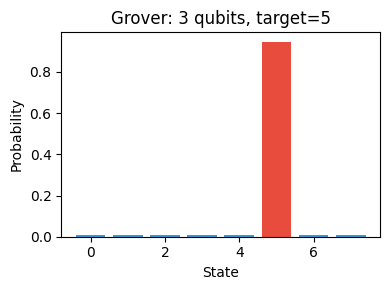

Target: 19 | P(target): 0.9992 | Measured: 19


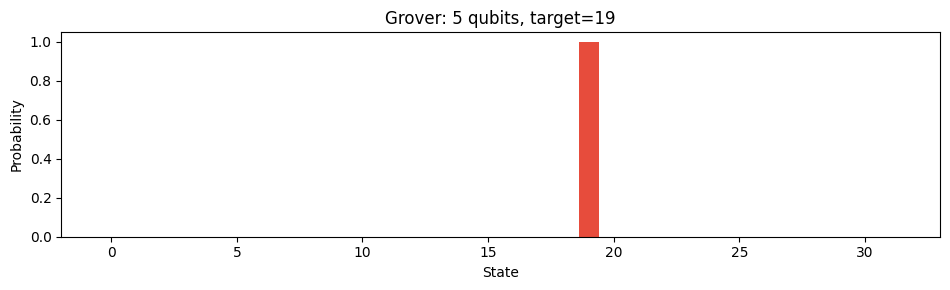

In [20]:
def run_grover(n_qubits, target):
    qe = QuantumEmulator(n_qubits)
    N = 2**n_qubits
    n_iters = floor(pi / 4 * sqrt(N))
    
    H = qe.hadamard(n_qubits)
    O = qe.oracle(n_qubits, target)
    D = qe.diffusion(n_qubits)
    
    qe.apply(H)
    for _ in range(n_iters):
        qe.apply(O)
        qe.apply(D)
    
    probs = qe.probabilities()
    return qe, probs


# 3-qubit search for target=5
qe, probs = run_grover(3, 5)
print(f'Target: 5 | P(target): {probs[5]:.4f} | Measured: {np.argmax(probs)}')
qe.plot(title='Grover: 3 qubits, target=5', target=5)

# 5-qubit search for target=19
qe, probs = run_grover(5, 19)
print(f'Target: 19 | P(target): {probs[19]:.4f} | Measured: {np.argmax(probs)}')
qe.plot(title='Grover: 5 qubits, target=19', target=19)

### The Exponential Wall

To feel the cost of classical emulation, let us time the Hadamard transform
for increasing qubit counts. Each additional qubit doubles the state vector
and quadruples the matrix size.

In [21]:
import time

print(f'{"Qubits":>6} {"States":>8} {"Matrix size":>14} {"Time (ms)":>10}')
print('-' * 42)

for n in range(2, 13):
    N = 2**n
    state = np.zeros(N, dtype=complex)
    state[0] = 1.0
    H = QuantumEmulator.hadamard(n)
    
    t0 = time.perf_counter()
    _ = H @ state
    dt = (time.perf_counter() - t0) * 1000
    
    print(f'{n:>6} {N:>8} {f"{N}x{N}":>14} {dt:>10.2f}')

print()
print('Each added qubit roughly doubles the time.')
print('At 30 qubits you need ~8 GB of RAM for the state vector alone.')
print('At 50 qubits, classical emulation becomes impractical.')

Qubits   States    Matrix size  Time (ms)
------------------------------------------
     2        4            4x4       0.01
     3        8            8x8       0.01
     4       16          16x16       0.01
     5       32          32x32       0.01
     6       64          64x64       0.01
     7      128        128x128       0.04
     8      256        256x256       0.10
     9      512        512x512       0.51
    10     1024      1024x1024       1.63
    11     2048      2048x2048       5.38


    12     4096      4096x4096      20.39

Each added qubit roughly doubles the time.
At 30 qubits you need ~8 GB of RAM for the state vector alone.
At 50 qubits, classical emulation becomes impractical.


## Summary

This chapter covered the full stack of quantum programming, from the hardware
model to high-level language design.

**Section 7.1**: The QRAM model splits computation between a classical master
and a quantum servant. The programmer writes classical code and offloads
quantum operations through a thin interface.

**Section 7.2**: A quantum assembler needs just four instructions:
INITIALIZE, SELECT, APPLY, and MEASURE. With CONCAT, TENSOR, and INVERSE
for gate construction, this is enough to express any quantum algorithm.
We built a working simulator and ran Deutsch's algorithm through it.

**Section 7.3**: Higher-level languages (QCL, Q, QFC/QPL, QML) aim to hide
the gate-level complexity behind compiler abstractions. The central challenge
is constructing $U_f$ for classical functions, which requires making
irreversible operations reversible at the cost of extra qubits.

**Section 7.4**: Classical emulation of quantum computation is possible
but grows exponentially with qubit count. For small registers, emulation
on a desktop is practical and valuable for learning. The `QuantumEmulator`
class we built can run Deutsch's, Grover's, and other small-scale algorithms.